# 04_s3 — SigCWGAN training on `_s3` log-signatures

This notebook is the **actual Stream 3 SigCWGAN training notebook**.

It reads the Notebook 3 `_s3` bundle, trains a **conditional WGAN-GP on log-signatures**, saves the best checkpoint and diagnostics, and writes:

- `sigcwgan_generated_logsigs.parquet`
- `sigcwgan_history.json`
- `sigcwgan_best.pt`
- `sigcwgan_config.json`

The conditioning contract is the shipped Stream 3 contract:

- 7 econometric scalars
- 9-way one-hot `regime_refined`
- 3 hazard features

for **19 conditioning dimensions total**.

### Setup

In [ ]:
%pip install -q torch optuna pandas pyarrow polars matplotlib numpy scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.1 MB/s eta 0:00:00


### CELL 1 — Imports, device, and file discovery

This cell tries to locate the Stream 3 artifacts automatically.  
If it finds the files in the wrong place, set `PROJECT_DIR` manually in the next cell.

In [ ]:
import copy
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

try:
    import optuna
except Exception:
    optuna = None

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


### CELL 2 — Paths and run parameters

In [ ]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
NOTEBOOK_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/notebooks")

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
assert NOTEBOOK_DIR.exists(), f"NOTEBOOK_DIR not found: {NOTEBOOK_DIR}"

LOGSIG_PATH = DATA_DIR / "logsigs_s3.parquet"
COND_STATS_PATH = DATA_DIR / "conditioning_stats_s3.json"
NORM_STATS_PATH = DATA_DIR / "norm_stats_s3.json"

RUN_TAG = "optuna_rawproxy_v1"
GENERATED_OUT = DATA_DIR / f"sigcwgan_generated_logsigs_{RUN_TAG}.parquet"
CHECKPOINT_OUT = DATA_DIR / f"sigcwgan_best_{RUN_TAG}.pt"
HISTORY_OUT = DATA_DIR / f"sigcwgan_history_{RUN_TAG}.json"
CONFIG_OUT = DATA_DIR / f"sigcwgan_config_{RUN_TAG}.json"

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

for p in [LOGSIG_PATH, COND_STATS_PATH, NORM_STATS_PATH]:
    assert p.exists(), f"Missing required file: {p}"

print("DATA_DIR:", DATA_DIR)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("LOGSIG_PATH:", LOGSIG_PATH)
print("COND_STATS_PATH:", COND_STATS_PATH)
print("NORM_STATS_PATH:", NORM_STATS_PATH)
print("RUN_TAG:", RUN_TAG)

# Core training controls
SEED = 42
USE_GPU_IF_AVAILABLE = True
RUN_OVERFIT_CHECK = False
RUN_BASELINE_TRAIN = False
USE_OPTUNA = True
RUN_FINAL_RETRAIN = True
SAVE_GENERATED_ALL_SPLITS = True

# Overfit / smoke test
OVERFIT_N = 256
OVERFIT_EPOCHS = 80

# Recommended starting config and final fallback
BASELINE_CONFIG = {
    "epochs": 220,
    "batch_size": 256,
    "noise_dim": 96,
    "hidden_dim": 384,
    "depth": 3,
    "dropout": 0.05,
    "critic_steps": 5,
    "lr_g": 2.0e-4,
    "lr_d": 1.0e-4,
    "beta1": 0.5,
    "beta2": 0.9,
    "gp_lambda": 7.5,
    "mean_match_weight": 0.25,
    "std_match_weight": 1.0,
    "patience": 35,
    "weight_decay": 3.0e-6,
}

# One-pass Optuna search, tuned toward the raw-space validator proxy
OPTUNA_TRIALS = 24
OPTUNA_EPOCHS = 140
OPTUNA_MAX_TRAIN = 4096
OPTUNA_MAX_VAL = 1024

# Selection objective weights
RAW_PROXY_WEIGHTS = {
    "mmd": 1.00,
    "mean": 0.25,
    "std": 1.00,
    "tail": 0.50,
    "cov": 0.25,
}

# Final retrain controls
FINAL_EPOCHS_OVERRIDE = None
GEN_SAMPLING_SEED = 123

# Sanity checks
for p in [LOGSIG_PATH, COND_STATS_PATH, NORM_STATS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Output files:")
print("  GENERATED_OUT:", GENERATED_OUT.name)
print("  CHECKPOINT_OUT:", CHECKPOINT_OUT.name)
print("  HISTORY_OUT:", HISTORY_OUT.name)
print("  CONFIG_OUT:", CONFIG_OUT.name)


Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/energy_synthetic_data/data
NOTEBOOK_DIR: /content/drive/MyDrive/energy_synthetic_data/notebooks
LOGSIG_PATH: /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s3.parquet
COND_STATS_PATH: /content/drive/MyDrive/energy_synthetic_data/data/conditioning_stats_s3.json
NORM_STATS_PATH: /content/drive/MyDrive/energy_synthetic_data/data/norm_stats_s3.json
RUN_TAG: optuna_rawproxy_v1
Output files:
  GENERATED_OUT: sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet
  CHECKPOINT_OUT: sigcwgan_best_optuna_rawproxy_v1.pt
  HISTORY_OUT: sigcwgan_history_optuna_rawproxy_v1.json
  CONFIG_OUT: sigcwgan_config_optuna_rawproxy_v1.json


### CELL 3 — Helpers

In [ ]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def find_file(filename: str, project_dir=None) -> Path:
    if project_dir is not None:
        project_dir = Path(project_dir)
        candidate = project_dir / filename
        if candidate.exists():
            return candidate

    search_roots = []
    for root in [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"), Path("/mnt/data")]:
        if root.exists():
            search_roots.append(root)

    # direct checks first
    for root in search_roots:
        direct = root / filename
        if direct.exists():
            return direct

    # shallow recursive search
    for root in search_roots:
        try:
            matches = list(root.rglob(filename))
        except Exception:
            matches = []
        if matches:
            matches = sorted(matches, key=lambda p: len(str(p)))
            return matches[0]

    raise FileNotFoundError(f"Could not find {filename}. Set PROJECT_DIR manually.")

def json_dump(obj, path: Path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def to_tensor(x, device=device):
    return torch.tensor(x, dtype=torch.float32, device=device)

def standardize_train_only(train_x: np.ndarray, full_x: np.ndarray, eps: float = 1e-8):
    mean = train_x.mean(axis=0)
    std = train_x.std(axis=0)
    std = np.where(std < eps, 1.0, std)
    return (full_x - mean) / std, mean, std

def make_loader(y, c, batch_size: int, shuffle: bool = True):
    ds = TensorDataset(
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(c, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

class MLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Generator(nn.Module):
    def __init__(self, noise_dim, cond_dim, out_dim, hidden_dim=256, depth=3, dropout=0.0):
        super().__init__()
        layers = [MLPBlock(noise_dim + cond_dim, hidden_dim, dropout=dropout)]
        for _ in range(depth - 1):
            layers.append(MLPBlock(hidden_dim, hidden_dim, dropout=dropout))
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, z, c):
        x = torch.cat([z, c], dim=1)
        h = self.backbone(x)
        return self.head(h)

class Critic(nn.Module):
    def __init__(self, in_dim, cond_dim, hidden_dim=256, depth=3, dropout=0.0):
        super().__init__()
        layers = [MLPBlock(in_dim + cond_dim, hidden_dim, dropout=dropout)]
        for _ in range(depth - 1):
            layers.append(MLPBlock(hidden_dim, hidden_dim, dropout=dropout))
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x, c):
        h = self.backbone(torch.cat([x, c], dim=1))
        return self.head(h)

def gradient_penalty(critic, real_x, fake_x, cond, device):
    batch_size = real_x.size(0)
    eps = torch.rand(batch_size, 1, device=device)
    interp = eps * real_x + (1 - eps) * fake_x
    interp.requires_grad_(True)

    scores = critic(interp, cond)
    grads = torch.autograd.grad(
        outputs=scores,
        inputs=interp,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grads = grads.view(batch_size, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

def pairwise_sq_dists(x, y):
    x2 = (x * x).sum(dim=1, keepdim=True)
    y2 = (y * y).sum(dim=1, keepdim=True).T
    return x2 + y2 - 2.0 * x @ y.T

def median_heuristic_sigma(x: torch.Tensor, max_points: int = 512):
    if x.shape[0] > max_points:
        idx = torch.randperm(x.shape[0], device=x.device)[:max_points]
        x = x[idx]
    d2 = pairwise_sq_dists(x, x)
    vals = d2.detach().cpu().numpy().ravel()
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    if len(vals) == 0:
        return 1.0
    sigma = float(np.sqrt(np.median(vals)))
    return max(sigma, 1e-3)

def rbf_mmd(x: torch.Tensor, y: torch.Tensor, sigma: float):
    gamma = 1.0 / (2.0 * sigma * sigma)
    k_xx = torch.exp(-gamma * pairwise_sq_dists(x, x))
    k_yy = torch.exp(-gamma * pairwise_sq_dists(y, y))
    k_xy = torch.exp(-gamma * pairwise_sq_dists(x, y))
    return k_xx.mean() + k_yy.mean() - 2.0 * k_xy.mean()

@torch.no_grad()
def generate_from_conditions(generator, cond_array, noise_dim, batch_size=512, seed=123, device=device):
    generator.eval()
    rng = torch.Generator(device=device)
    rng.manual_seed(seed)

    cond_t = torch.tensor(cond_array, dtype=torch.float32, device=device)
    outs = []
    for start in range(0, len(cond_t), batch_size):
        c = cond_t[start:start + batch_size]
        z = torch.randn((len(c), noise_dim), generator=rng, device=device)
        fake = generator(z, c)
        outs.append(fake.detach().cpu().numpy())
    return np.vstack(outs)

def _destandardize_if_available(x: np.ndarray) -> np.ndarray:
    if "y_mean" in globals() and "y_std" in globals():
        return x * y_std.astype(np.float32) + y_mean.astype(np.float32)
    return x

def _tail_gap_relative(real_x: np.ndarray, fake_x: np.ndarray, eps: float = 1e-6) -> float:
    q_real = np.quantile(real_x, [0.01, 0.05, 0.95, 0.99], axis=0)
    q_fake = np.quantile(fake_x, [0.01, 0.05, 0.95, 0.99], axis=0)
    spread = np.maximum(q_real[2] - q_real[1], eps)
    rel_err = np.abs(q_real - q_fake) / spread[None, :]
    return float(np.mean(rel_err))

def _cov_gap_relative(real_x: np.ndarray, fake_x: np.ndarray, max_dims: int = 24, eps: float = 1e-6) -> float:
    if real_x.shape[1] <= 1:
        return 0.0
    idx = np.argsort(np.std(real_x, axis=0))[-min(max_dims, real_x.shape[1]):]
    xr = real_x[:, idx]
    xf = fake_x[:, idx]
    cov_r = np.cov(xr, rowvar=False)
    cov_f = np.cov(xf, rowvar=False)
    scale = float(np.mean(np.abs(cov_r))) + eps
    return float(np.mean(np.abs(cov_r - cov_f)) / scale)

def evaluate_generator(generator, y_val, c_val, noise_dim, sigma=None, seed=123, device=device):
    y_real_std = torch.tensor(y_val, dtype=torch.float32, device=device)
    y_fake_std_np = generate_from_conditions(generator, c_val, noise_dim=noise_dim, seed=seed, device=device)
    y_fake_std = torch.tensor(y_fake_std_np, dtype=torch.float32, device=device)

    if sigma is None:
        sigma = median_heuristic_sigma(y_real_std)
    mmd = float(rbf_mmd(y_real_std, y_fake_std, sigma=sigma).item())

    y_real_raw = _destandardize_if_available(y_val.astype(np.float32))
    y_fake_raw = _destandardize_if_available(y_fake_std_np.astype(np.float32))

    mean_gap = float(np.mean(np.abs(y_real_raw.mean(axis=0) - y_fake_raw.mean(axis=0))))
    std_gap = float(np.mean(np.abs(y_real_raw.std(axis=0) - y_fake_raw.std(axis=0))))
    tail_gap = _tail_gap_relative(y_real_raw, y_fake_raw)
    cov_gap = _cov_gap_relative(y_real_raw, y_fake_raw, max_dims=24)

    score = (
        RAW_PROXY_WEIGHTS["mmd"] * mmd
        + RAW_PROXY_WEIGHTS["mean"] * mean_gap
        + RAW_PROXY_WEIGHTS["std"] * std_gap
        + RAW_PROXY_WEIGHTS["tail"] * tail_gap
        + RAW_PROXY_WEIGHTS["cov"] * cov_gap
    )

    return {
        "score": float(score),
        "mmd_rbf": mmd,
        "mean_gap": mean_gap,
        "std_gap": std_gap,
        "tail_gap": tail_gap,
        "cov_gap": cov_gap,
        "sigma": float(sigma),
    }

def train_sigcwgan(
    y_train,
    c_train,
    y_val,
    c_val,
    config,
    run_name="baseline",
    seed=42,
    device=device,
    verbose_every=10,
):
    seed_everything(seed)

    y_dim = y_train.shape[1]
    c_dim = c_train.shape[1]

    G = Generator(
        noise_dim=config["noise_dim"],
        cond_dim=c_dim,
        out_dim=y_dim,
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        dropout=config["dropout"],
    ).to(device)

    D = Critic(
        in_dim=y_dim,
        cond_dim=c_dim,
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        dropout=config["dropout"],
    ).to(device)

    opt_g = torch.optim.Adam(
        G.parameters(),
        lr=config["lr_g"],
        betas=(config["beta1"], config["beta2"]),
        weight_decay=config.get("weight_decay", 0.0),
    )
    opt_d = torch.optim.Adam(
        D.parameters(),
        lr=config["lr_d"],
        betas=(config["beta1"], config["beta2"]),
        weight_decay=config.get("weight_decay", 0.0),
    )

    scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=config["epochs"])
    scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=config["epochs"])

    train_loader = make_loader(y_train, c_train, batch_size=config["batch_size"], shuffle=True)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)
    sigma_val = median_heuristic_sigma(y_val_t)

    history = []
    best = {
        "score": float("inf"),
        "epoch": -1,
        "state_G": None,
        "state_D": None,
        "metrics": None,
    }
    bad_epochs = 0

    start_time = time.time()

    for epoch in range(1, config["epochs"] + 1):
        G.train()
        D.train()

        d_losses = []
        g_losses = []
        gp_vals = []

        for real_x, cond in train_loader:
            real_x = real_x.to(device)
            cond = cond.to(device)

            # Critic steps
            for _ in range(config["critic_steps"]):
                z = torch.randn(real_x.size(0), config["noise_dim"], device=device)
                fake_x = G(z, cond).detach()

                d_real = D(real_x, cond).mean()
                d_fake = D(fake_x, cond).mean()
                gp = gradient_penalty(D, real_x, fake_x, cond, device=device)

                d_loss = d_fake - d_real + config["gp_lambda"] * gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            # Generator step
            z = torch.randn(real_x.size(0), config["noise_dim"], device=device)
            fake_x = G(z, cond)

            adv_loss = -D(fake_x, cond).mean()
            mean_match = torch.mean((fake_x.mean(0) - real_x.mean(0)) ** 2)
            std_match = torch.mean((fake_x.std(0) - real_x.std(0)) ** 2)

            g_loss = (
                adv_loss
                + config["mean_match_weight"] * mean_match
                + config["std_match_weight"] * std_match
            )

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_losses.append(float(d_loss.item()))
            g_losses.append(float(g_loss.item()))
            gp_vals.append(float(gp.item()))

        scheduler_g.step()
        scheduler_d.step()

        metrics = evaluate_generator(
            G, y_val, c_val,
            noise_dim=config["noise_dim"],
            sigma=sigma_val,
            seed=seed + epoch,
            device=device,
        )
        metrics.update({
            "epoch": epoch,
            "d_loss": float(np.mean(d_losses)),
            "g_loss": float(np.mean(g_losses)),
            "gp": float(np.mean(gp_vals)),
        })
        history.append(metrics)

        if metrics["score"] < best["score"]:
            best["score"] = metrics["score"]
            best["epoch"] = epoch
            best["metrics"] = copy.deepcopy(metrics)
            best["state_G"] = copy.deepcopy(G.state_dict())
            best["state_D"] = copy.deepcopy(D.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % verbose_every == 0:
            print(
                f"[{run_name}] epoch {epoch:03d} | "
                f"D {metrics['d_loss']:.4f} | G {metrics['g_loss']:.4f} | "
                f"MMD {metrics['mmd_rbf']:.4f} | mean_gap {metrics['mean_gap']:.4f} | "
                f"std_gap {metrics['std_gap']:.4f} | tail_gap {metrics['tail_gap']:.4f} | cov_gap {metrics['cov_gap']:.4f} | score {metrics['score']:.4f}"
            )

        if bad_epochs >= config["patience"]:
            print(f"[{run_name}] early stop at epoch {epoch} (patience reached)")
            break

    elapsed = time.time() - start_time
    print(f"[{run_name}] best epoch: {best['epoch']} | best score: {best['score']:.4f} | elapsed: {elapsed/60:.1f} min")

    if best["state_G"] is None:
        raise RuntimeError("Training finished without a saved best checkpoint.")

    G.load_state_dict(best["state_G"])
    D.load_state_dict(best["state_D"])

    return {
        "generator": G,
        "critic": D,
        "best": best,
        "history": history,
        "elapsed_seconds": elapsed,
        "n_params_generator": count_parameters(G),
        "n_params_critic": count_parameters(D),
    }

def plot_history(history, title="SigCWGAN history"):
    hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(hist["epoch"], hist["d_loss"], label="critic")
    axes[0].plot(hist["epoch"], hist["g_loss"], label="generator")
    axes[0].set_title("Training losses")
    axes[0].legend()

    axes[1].plot(hist["epoch"], hist["mmd_rbf"], label="val MMD")
    axes[1].plot(hist["epoch"], hist["score"], label="selection score")
    axes[1].set_title("Validation proxy score")
    axes[1].legend()

    axes[2].plot(hist["epoch"], hist["mean_gap"], label="mean gap")
    axes[2].plot(hist["epoch"], hist["std_gap"], label="std gap")
    axes[2].set_title("Raw-space moment gaps")
    axes[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def pca_real_vs_fake(y_real, y_fake, split_name="test"):
    x = np.vstack([y_real, y_fake])
    labels = np.array(["real"] * len(y_real) + ["fake"] * len(y_fake))
    x = (x - x.mean(axis=0)) / np.where(x.std(axis=0) < 1e-8, 1.0, x.std(axis=0))
    pca = PCA(n_components=2)
    xp = pca.fit_transform(x)

    fig, ax = plt.subplots(figsize=(8, 6))
    for lab, alpha in [("real", 0.35), ("fake", 0.35)]:
        mask = labels == lab
        ax.scatter(xp[mask, 0], xp[mask, 1], s=8, alpha=alpha, label=lab)
    ax.set_title(f"PCA real vs fake log-signatures ({split_name})")
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

def marginal_diagnostic(y_real, y_fake, cols, max_plots=6):
    cols = cols[:max_plots]
    fig, axes = plt.subplots(len(cols), 1, figsize=(8, 3 * len(cols)))
    if len(cols) == 1:
        axes = [axes]
    for ax, idx in zip(axes, cols):
        ax.hist(y_real[:, idx], bins=40, alpha=0.5, density=True, label="real")
        ax.hist(y_fake[:, idx], bins=40, alpha=0.5, density=True, label="fake")
        ax.set_title(f"logsig dim {idx}")
        ax.legend()
    plt.tight_layout()
    plt.show()


### CELL 4 — Load Stream 3 bundle and exact column contract

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Load Stream 3 training bundle from fixed data paths
# ═══════════════════════════════════════════════════════════════════════════

df = pd.read_parquet(LOGSIG_PATH)

with open(COND_STATS_PATH, "r") as f:
    cond_stats = json.load(f)

with open(NORM_STATS_PATH, "r") as f:
    norm_stats = json.load(f)

ls_cols = sorted(
    [c for c in df.columns if c.startswith("ls_")],
    key=lambda x: int(x.split("_")[1])
)

cond_cols = cond_stats["all_conditioning_cols"]
scalar_cond_cols = cond_stats["econometric_scalar_cols_cond"]
regime_cols = cond_stats["regime_onehot_cols"]
hazard_cond_cols = cond_stats["hazard_cols_cond"]

required_meta_cols = ["segment_id", "start_time", "start_idx", "end_idx", "split", "regime"]

missing = [c for c in required_meta_cols + ls_cols + cond_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in logsigs_s3.parquet: {missing[:20]}")

assert int(norm_stats["path_dim"]) == 4, f"Expected path_dim=4, got {norm_stats['path_dim']}"
assert int(norm_stats["sig_depth"]) == 4, f"Expected sig_depth=4, got {norm_stats['sig_depth']}"
assert int(norm_stats["logsig_dim"]) == 90, f"Expected logsig_dim metadata to be 90, got {norm_stats['logsig_dim']}"
assert len(ls_cols) == 90, f"Expected 90 log-signature columns, got {len(ls_cols)}"
assert len(scalar_cond_cols) == 7, f"Expected 7 scalar cond cols, got {len(scalar_cond_cols)}"
assert len(regime_cols) == 9, f"Expected 9 regime one-hot cols, got {len(regime_cols)}"
assert len(hazard_cond_cols) == 3, f"Expected 3 hazard cond cols, got {len(hazard_cond_cols)}"
assert len(cond_cols) == 19, f"Expected 19 conditioning cols, got {len(cond_cols)}"

# Defensive split repair: do not trust the saved split labels blindly.
# Notebook 03 previously inherited overlapping date ranges from hazard_fit.json,
# which could collapse almost everything into train and leave only ~33 test rows.
df = df.sort_values(["start_idx", "end_idx", "start_time"]).reset_index(drop=True).copy()
df["split_saved"] = df["split"].astype(str)

train_frac = 0.70
val_frac = 0.15
test_frac = 0.15
segment_length = int(norm_stats.get("segment_length", 72))
step_size = int(norm_stats.get("step_size", 24))
embargo_bins = segment_length

n = len(df)
n_train = int(np.floor(train_frac * n))
n_val = int(np.floor(val_frac * n))
n_test = n - n_train - n_val

b1 = n_train
b2 = n_train + n_val

boundary1 = int(df.loc[b1, "start_idx"])
boundary2 = int(df.loc[b2, "start_idx"])

start_idx = pd.to_numeric(df["start_idx"], errors="raise").to_numpy(dtype=np.int64)
end_idx = pd.to_numeric(df["end_idx"], errors="raise").to_numpy(dtype=np.int64)

split_recomputed = np.full(n, "embargo", dtype=object)
split_recomputed[end_idx <= (boundary1 - embargo_bins)] = "train"
split_recomputed[
    (start_idx >= (boundary1 + embargo_bins)) & (end_idx <= (boundary2 - embargo_bins))
] = "val"
split_recomputed[start_idx >= (boundary2 + embargo_bins)] = "test"

df["split"] = split_recomputed

print(f"Bundle shape: {df.shape}")
print("\nSaved split counts:")
print(df['split_saved'].value_counts(dropna=False).sort_index())

print("\nRecomputed split counts:")
print(df['split'].value_counts(dropna=False).sort_index())

print("\nColumn blocks:")
print(f"  log-signatures: {len(ls_cols)}")
print(f"  conditioning:   {len(cond_cols)}")
print(f"  scalar block:   {len(scalar_cond_cols)}")
print(f"  regime block:   {len(regime_cols)}")
print(f"  hazard block:   {len(hazard_cond_cols)}")

X_all = df[ls_cols].to_numpy(dtype=np.float32)
C_all = df[cond_cols].to_numpy(dtype=np.float32)

train_mask = df["split"].eq("train").to_numpy()
val_mask   = df["split"].eq("val").to_numpy()
test_mask  = df["split"].eq("test").to_numpy()

if min(train_mask.sum(), val_mask.sum(), test_mask.sum()) <= 0:
    raise RuntimeError(
        f"Bad recomputed split sizes: train={train_mask.sum()}, val={val_mask.sum()}, test={test_mask.sum()}"
    )

X_train, C_train = X_all[train_mask], C_all[train_mask]
X_val,   C_val   = X_all[val_mask],   C_all[val_mask]
X_test,  C_test  = X_all[test_mask],  C_all[test_mask]

print("\nTensor-ready shapes:")
print("  X_train:", X_train.shape, " C_train:", C_train.shape)
print("  X_val:  ", X_val.shape,   " C_val:  ", C_val.shape)
print("  X_test: ", X_test.shape,  " C_test: ", C_test.shape)


Bundle shape: (6514, 133)

Saved split counts:
split_saved
test      977
train    4566
val       971
Name: count, dtype: int64

Recomputed split counts:
split
embargo      14
test        977
train      4554
val         969
Name: count, dtype: int64

Column blocks:
  log-signatures: 90
  conditioning:   19
  scalar block:   7
  regime block:   9
  hazard block:   3

Tensor-ready shapes:
  X_train: (4554, 90)  C_train: (4554, 19)
  X_val:   (969, 90)  C_val:   (969, 19)
  X_test:  (977, 90)  C_test:  (977, 19)


### CELL 5 — Prepare train / val / test arrays

In [ ]:
df = df[df["split"].isin(["train", "val", "test"])].copy()

for c in ls_cols + cond_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# We expect conditioning columns to be complete after Notebook 3.
cond_missing = df[cond_cols].isna().sum().sum()
if cond_missing != 0:
    raise ValueError(f"Conditioning columns contain {cond_missing} missing values.")

# Guard against accidental training on helper columns: use exact lists only.
meta_cols = [c for c in required_meta_cols if c in df.columns]
train_mask = df["split"] == "train"
val_mask = df["split"] == "val"
test_mask = df["split"] == "test"

Y_full_raw = df[ls_cols].to_numpy(dtype=np.float32)
C_full = df[cond_cols].to_numpy(dtype=np.float32)

Y_full, y_mean, y_std = standardize_train_only(
    train_x=Y_full_raw[train_mask.to_numpy()],
    full_x=Y_full_raw,
)

Y_train = Y_full[train_mask.to_numpy()]
C_train = C_full[train_mask.to_numpy()]

Y_val = Y_full[val_mask.to_numpy()]
C_val = C_full[val_mask.to_numpy()]

Y_test = Y_full[test_mask.to_numpy()]
C_test = C_full[test_mask.to_numpy()]

print("Array shapes:")
print("  Y_train:", Y_train.shape, "| C_train:", C_train.shape)
print("  Y_val:  ", Y_val.shape, "| C_val:  ", C_val.shape)
print("  Y_test: ", Y_test.shape, "| C_test: ", C_test.shape)

print("\nStandardisation sanity:")
print("  train mean | abs max:", float(np.abs(Y_train.mean(axis=0)).max()))
print("  train std  | min/max:", float(Y_train.std(axis=0).min()), float(Y_train.std(axis=0).max()))

Array shapes:
  Y_train: (4554, 90) | C_train: (4554, 19)
  Y_val:   (969, 90) | C_val:   (969, 19)
  Y_test:  (977, 90) | C_test:  (977, 19)

Standardisation sanity:
  train mean | abs max: 5.570697794610169e-06
  train std  | min/max: 0.0 1.000002145767212


### CELL 6 — Baseline config summary

In [ ]:
print("Baseline config:")
for k, v in BASELINE_CONFIG.items():
    print(f"  {k}: {v}")

if torch.cuda.is_available():
    print("\nGPU training is available and should be used for full training.")
else:
    print("\nNo GPU detected. Full training will be much slower on CPU.")

Baseline config:
  epochs: 220
  batch_size: 256
  noise_dim: 96
  hidden_dim: 384
  depth: 3
  dropout: 0.05
  critic_steps: 5
  lr_g: 0.0002
  lr_d: 0.0001
  beta1: 0.5
  beta2: 0.9
  gp_lambda: 7.5
  mean_match_weight: 0.25
  std_match_weight: 1.0
  patience: 35
  weight_decay: 3e-06

GPU training is available and should be used for full training.


### CELL 7 — Optional overfit-on-small-sample check

In [ ]:
overfit_result = None

if RUN_OVERFIT_CHECK:
    n = min(OVERFIT_N, len(Y_train))
    overfit_cfg = copy.deepcopy(BASELINE_CONFIG)
    overfit_cfg["epochs"] = OVERFIT_EPOCHS
    overfit_cfg["patience"] = min(overfit_cfg["patience"], 20)

    overfit_result = train_sigcwgan(
        y_train=Y_train[:n],
        c_train=C_train[:n],
        y_val=Y_train[:n],
        c_val=C_train[:n],
        config=overfit_cfg,
        run_name="overfit",
        seed=SEED,
        device=device,
        verbose_every=10,
    )
    plot_history(overfit_result["history"], title="Overfit check history")
else:
    print("RUN_OVERFIT_CHECK = False -> skipping")

RUN_OVERFIT_CHECK = False -> skipping


### CELL 8 — Baseline full training

In [ ]:
baseline_result = None

if RUN_BASELINE_TRAIN:
    baseline_result = train_sigcwgan(
        y_train=Y_train,
        c_train=C_train,
        y_val=Y_val,
        c_val=C_val,
        config=copy.deepcopy(BASELINE_CONFIG),
        run_name="baseline",
        seed=SEED,
        device=device,
        verbose_every=10,
    )
    plot_history(baseline_result["history"], title="Baseline SigCWGAN history")
else:
    print("RUN_BASELINE_TRAIN = False -> skipping")

RUN_BASELINE_TRAIN = False -> skipping


### CELL 9 — Optional Optuna tuning

Recommended use:
- leave this **off** until the baseline finishes cleanly
- use a **Colab GPU**
- keep the search narrow and practical

This tunes only a handful of load-bearing hyperparameters and uses a shorter training horizon than the final retrain.

In [ ]:
optuna_best = None
optuna_study = None

if USE_OPTUNA:
    if optuna is None:
        raise ImportError("Optuna is not installed correctly in this runtime.")

    train_idx = np.arange(len(Y_train))
    val_idx = np.arange(len(Y_val))

    if len(train_idx) > OPTUNA_MAX_TRAIN:
        rng = np.random.default_rng(SEED)
        train_idx = rng.choice(train_idx, size=OPTUNA_MAX_TRAIN, replace=False)
    if len(val_idx) > OPTUNA_MAX_VAL:
        rng = np.random.default_rng(SEED + 1)
        val_idx = rng.choice(val_idx, size=OPTUNA_MAX_VAL, replace=False)

    y_train_tune = Y_train[train_idx]
    c_train_tune = C_train[train_idx]
    y_val_tune = Y_val[val_idx]
    c_val_tune = C_val[val_idx]

    def objective(trial):
        cfg = {
            "epochs": OPTUNA_EPOCHS,
            "batch_size": trial.suggest_categorical("batch_size", [256]),
            "noise_dim": trial.suggest_categorical("noise_dim", [64, 96]),
            "hidden_dim": trial.suggest_categorical("hidden_dim", [256, 384]),
            "depth": trial.suggest_categorical("depth", [3, 4]),
            "dropout": trial.suggest_categorical("dropout", [0.03, 0.05, 0.08]),
            "critic_steps": trial.suggest_categorical("critic_steps", [5]),
            "lr_g": trial.suggest_float("lr_g", 1.0e-4, 4.0e-4, log=True),
            "lr_d": trial.suggest_float("lr_d", 5.0e-5, 2.0e-4, log=True),
            "beta1": trial.suggest_categorical("beta1", [0.0, 0.5]),
            "beta2": trial.suggest_categorical("beta2", [0.9, 0.99]),
            "gp_lambda": trial.suggest_categorical("gp_lambda", [5.0, 7.5, 10.0]),
            "mean_match_weight": 0.25,
            "std_match_weight": 1.0,
            "patience": 28,
            "weight_decay": trial.suggest_categorical("weight_decay", [1.0e-6, 3.0e-6, 1.0e-5]),
        }

        result = train_sigcwgan(
            y_train=y_train_tune,
            c_train=c_train_tune,
            y_val=y_val_tune,
            c_val=c_val_tune,
            config=cfg,
            run_name=f"trial_{trial.number}",
            seed=SEED + trial.number,
            device=device,
            verbose_every=999,
        )
        best_metrics = result["best"]["metrics"]
        trial.set_user_attr("best_epoch", int(result["best"]["epoch"]))
        trial.set_user_attr("mmd_rbf", float(best_metrics["mmd_rbf"]))
        trial.set_user_attr("mean_gap", float(best_metrics["mean_gap"]))
        trial.set_user_attr("std_gap", float(best_metrics["std_gap"]))
        trial.set_user_attr("tail_gap", float(best_metrics["tail_gap"]))
        trial.set_user_attr("cov_gap", float(best_metrics["cov_gap"]))
        return float(result["best"]["score"])

    sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, constant_liar=True)
    optuna_study = optuna.create_study(direction="minimize", sampler=sampler)
    optuna_study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    optuna_best = copy.deepcopy(optuna_study.best_params)
    optuna_best.update({
        "epochs": BASELINE_CONFIG["epochs"],
        "patience": BASELINE_CONFIG["patience"],
        "mean_match_weight": BASELINE_CONFIG["mean_match_weight"],
        "std_match_weight": BASELINE_CONFIG["std_match_weight"],
    })

    print("Best Optuna proxy score:", optuna_study.best_value)
    print("Best Optuna params:")
    for k, v in optuna_best.items():
        print(f"  {k}: {v}")
    print("Best trial attrs:")
    for k, v in optuna_study.best_trial.user_attrs.items():
        print(f"  {k}: {v}")
else:
    print("USE_OPTUNA = False -> skipping")


/tmp/ipykernel_424/1957128213.py:63: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, constant_liar=True)
/tmp/ipykernel_424/1957128213.py:63: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, constant_liar=True)
[I 2026-04-15 15:57:22,347] A new study created in memory with name: no-name-217290c7-9391-40da-b19d-4d1c18ca8f49


  0%|          | 0/24 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[trial_0] epoch 001 | D 0.2636 | G 0.7174 | MMD 0.0886 | mean_gap 1.9254 | std_gap 4.3066 | tail_gap 6530.9671 | cov_gap 0.9696 | score 3270.6025
[trial_0] best epoch: 116 | best score: 1469.5035 | elapsed: 2.0 min
[I 2026-04-15 15:59:25,216] Trial 0 finished with value: 1469.5034649826803 and parameters: {'batch_size': 256, 'noise_dim': 96, 'hidden_dim': 256, 'depth': 3, 'dropout': 0.05, 'critic_steps': 5, 'lr_g': 0.00026687148364280106, 'lr_d': 5.144736127521132e-05, 'beta1': 0.0, 'beta2': 0.9, 'gp_lambda': 10.0, 'weight_decay': 1e-05}. Best is trial 0 with value: 1469.5034649826803.
[trial_1] epoch 001 | D -0.6417 | G 1.1856 | MMD 0.0920 | mean_gap 2.3733 | std_gap 4.1458 | tail_gap 6265.2990 | cov_gap 0.9713 | score 3137.7235
[trial_1] best epoch: 140 | best score: 1015.6707 | elapsed: 1.9 min
[I 2026-04-15 16:01:22,097] Trial 1 finished with value: 1015.6706537081625 and parameters: {'batch_size': 256, 'noise_dim': 96, 'hidden_dim': 384, 'depth': 3, 'dropout': 0.05, 'critic_steps'

### CELL 10 — Final config selection

In [ ]:
if optuna_best is not None:
    FINAL_CONFIG = copy.deepcopy(optuna_best)
    FINAL_CONFIG_SOURCE = "optuna_rawproxy"
else:
    FINAL_CONFIG = copy.deepcopy(BASELINE_CONFIG)
    FINAL_CONFIG_SOURCE = "recommended_default"

if FINAL_EPOCHS_OVERRIDE is not None:
    FINAL_CONFIG["epochs"] = int(FINAL_EPOCHS_OVERRIDE)

print("Final config source:", FINAL_CONFIG_SOURCE)
for k, v in FINAL_CONFIG.items():
    print(f"  {k}: {v}")


Final config source: optuna_rawproxy
  batch_size: 256
  noise_dim: 96
  hidden_dim: 256
  depth: 4
  dropout: 0.08
  critic_steps: 5
  lr_g: 0.0003503989125392171
  lr_d: 0.0001963891715100981
  beta1: 0.0
  beta2: 0.9
  gp_lambda: 10.0
  weight_decay: 3e-06
  epochs: 220
  patience: 35
  mean_match_weight: 0.25
  std_match_weight: 1.0


### CELL 11 — Final retrain with selected config

[final] epoch 001 | D -0.9242 | G 1.6453 | MMD 0.0537 | mean_gap 1.2267 | std_gap 3.7793 | tail_gap 8143.5604 | cov_gap 0.9766 | score 4076.1640
[final] epoch 010 | D -2.4983 | G 4.8700 | MMD 0.0178 | mean_gap 1.2666 | std_gap 1.6820 | tail_gap 4664.3367 | cov_gap 0.5235 | score 2334.3157
[final] epoch 020 | D -2.2039 | G 6.7057 | MMD 0.0092 | mean_gap 0.9841 | std_gap 1.3553 | tail_gap 3303.2999 | cov_gap 0.4711 | score 1653.3783
[final] epoch 030 | D -2.0193 | G 7.5190 | MMD 0.0123 | mean_gap 0.7912 | std_gap 1.2271 | tail_gap 2718.5482 | cov_gap 0.4136 | score 1360.8147
[final] epoch 040 | D -1.8804 | G 8.0381 | MMD 0.0079 | mean_gap 0.8064 | std_gap 1.0970 | tail_gap 2043.3711 | cov_gap 0.4038 | score 1023.0930
[final] epoch 050 | D -1.7501 | G 8.0849 | MMD 0.0079 | mean_gap 0.9107 | std_gap 1.3542 | tail_gap 1736.8984 | cov_gap 0.4034 | score 870.1399
[final] epoch 060 | D -1.7407 | G 8.2421 | MMD 0.0063 | mean_gap 0.7931 | std_gap 1.0512 | tail_gap 1428.9252 | cov_gap 0.4046 | sc

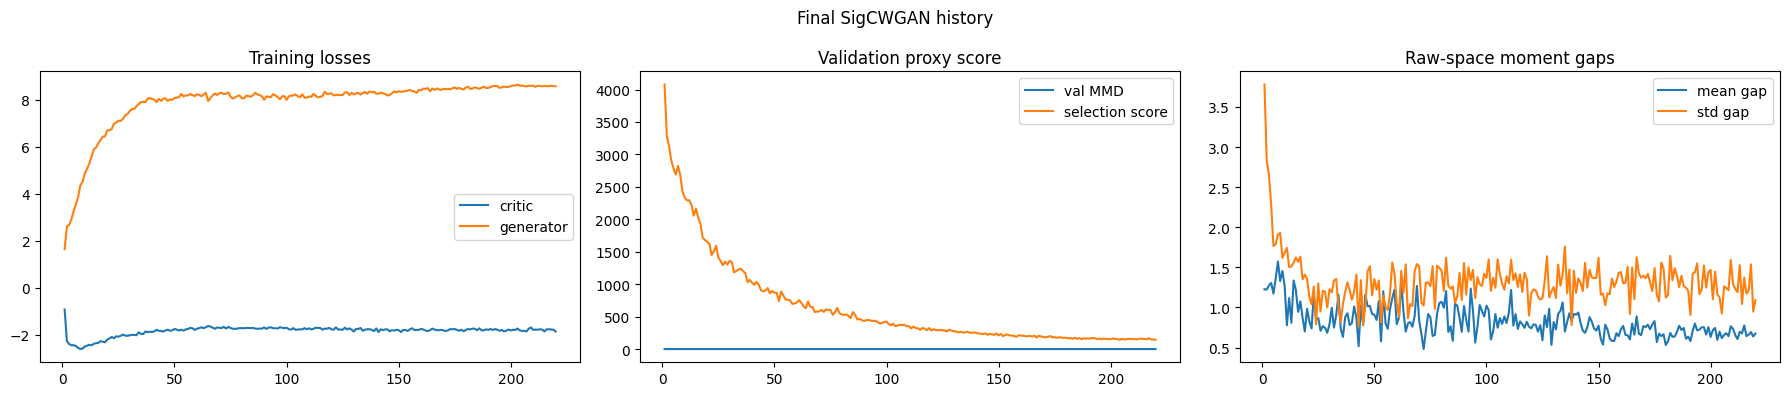

In [ ]:
final_result = None

if RUN_FINAL_RETRAIN:
    final_result = train_sigcwgan(
        y_train=Y_train,
        c_train=C_train,
        y_val=Y_val,
        c_val=C_val,
        config=copy.deepcopy(FINAL_CONFIG),
        run_name="final",
        seed=SEED,
        device=device,
        verbose_every=10,
    )
    plot_history(final_result["history"], title="Final SigCWGAN history")
else:
    print("RUN_FINAL_RETRAIN = False -> skipping")

### CELL 12 — Save checkpoint, config, and history

In [ ]:
STREAM_TAG = "s3"

if final_result is None:
    raise RuntimeError("No final_result available. Run CELL 11 first.")

checkpoint_path = DATA_DIR / CHECKPOINT_OUT
history_path = DATA_DIR / HISTORY_OUT
config_path = DATA_DIR / CONFIG_OUT

checkpoint_payload = {
    "generator_state_dict": final_result["generator"].state_dict(),
    "critic_state_dict": final_result["critic"].state_dict(),
    "best_epoch": int(final_result["best"]["epoch"]),
    "best_metrics": final_result["best"]["metrics"],
    "config": FINAL_CONFIG,
    "logsig_cols": ls_cols,
    "conditioning_cols": cond_cols,
    "y_mean": y_mean.astype(np.float32),
    "y_std": y_std.astype(np.float32),
    "seed": SEED,
    "stream_tag": STREAM_TAG,
}
torch.save(checkpoint_payload, checkpoint_path)

history_payload = {
    "stream_tag": STREAM_TAG,
    "config_source": FINAL_CONFIG_SOURCE,
    "config": FINAL_CONFIG,
    "best_epoch": int(final_result["best"]["epoch"]),
    "best_metrics": final_result["best"]["metrics"],
    "elapsed_seconds": float(final_result["elapsed_seconds"]),
    "n_params_generator": int(final_result["n_params_generator"]),
    "n_params_critic": int(final_result["n_params_critic"]),
    "history": final_result["history"],
}
json_dump(history_payload, history_path)

config_payload = {
    "stream_tag": STREAM_TAG,
    "config_source": FINAL_CONFIG_SOURCE,
    "seed": SEED,
    "generator_type": "conditional_wgan_gp_on_logsignatures",
    "noise_dim": int(FINAL_CONFIG["noise_dim"]),
    "logsig_dim": int(len(ls_cols)),
    "conditioning_dim": int(len(cond_cols)),
    "conditioning_cols": cond_cols,
    "logsig_cols": ls_cols,
    "meta_cols": meta_cols,
    "train_rows": int(train_mask.sum()),
    "val_rows": int(val_mask.sum()),
    "test_rows": int(test_mask.sum()),
    "best_epoch": int(final_result["best"]["epoch"]),
    "best_metrics": final_result["best"]["metrics"],
    "note": "Notebook 4 uses a raw-space Optuna proxy: MMD + 0.25*mean_gap + 1.0*std_gap + 0.5*tail_gap + 0.25*cov_gap. Exact ls_* and conditioning cols only.",
    "run_tag": RUN_TAG,
}
json_dump(config_payload, config_path)

print("Saved checkpoint:", checkpoint_path.name)
print("Saved history:   ", history_path.name)
print("Saved config:    ", config_path.name)
print("Best validation metrics:")
print(pd.Series(final_result["best"]["metrics"]))


Saved checkpoint: sigcwgan_best_optuna_rawproxy_v1.pt
Saved history:    sigcwgan_history_optuna_rawproxy_v1.json
Saved config:     sigcwgan_config_optuna_rawproxy_v1.json
Best validation metrics:
score       142.207522
mmd_rbf       0.004568
mean_gap      0.698212
std_gap       1.127155
tail_gap    281.580377
cov_gap       0.444229
sigma        11.018340
epoch       204.000000
d_loss       -1.808700
g_loss        8.611904
gp            0.041981
dtype: float64


### CELL 13 — Generate `sigcwgan_generated_logsigs.parquet`

In [ ]:
if final_result is None:
    raise RuntimeError("No final_result available. Run training first.")

seed_everything(GEN_SAMPLING_SEED)

if SAVE_GENERATED_ALL_SPLITS:
    row_mask = np.ones(len(df), dtype=bool)
else:
    row_mask = test_mask.to_numpy()

df_out = df.loc[row_mask].copy()
C_out = df_out[cond_cols].to_numpy(dtype=np.float32)

Y_fake_std = generate_from_conditions(
    final_result["generator"],
    C_out,
    noise_dim=FINAL_CONFIG["noise_dim"],
    seed=GEN_SAMPLING_SEED,
    device=device,
)
Y_fake = Y_fake_std * y_std + y_mean

for j, col in enumerate(ls_cols):
    df_out[col] = Y_fake[:, j]

df_out["generator_name"] = "sigcwgan"
df_out["generator_stream"] = STREAM_TAG
df_out["generator_seed"] = int(GEN_SAMPLING_SEED)
df_out["generator_best_epoch"] = int(final_result["best"]["epoch"])
df_out["generator_config_source"] = FINAL_CONFIG_SOURCE

generated_path = DATA_DIR / GENERATED_OUT
df_out.to_parquet(generated_path, index=False)

print("Saved:", generated_path.name)
print("  Shape:", df_out.shape)
print("  Size: ", f"{generated_path.stat().st_size / 1e6:.2f} MB")
print("\nSplit counts in generated output:")
print(df_out["split"].value_counts().sort_index())

Saved: sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet
  Shape: (6500, 138)
  Size:  4.91 MB

Split counts in generated output:
split
test      977
train    4554
val       969
Name: count, dtype: int64


### CELL 14 — Diagnostics on generated test set

Held-out TEST metrics:
score       140.484096
mmd_rbf       0.007825
mean_gap      0.712390
std_gap       0.882010
tail_gap    278.650393
cov_gap       0.363866
sigma        10.640213
dtype: float64


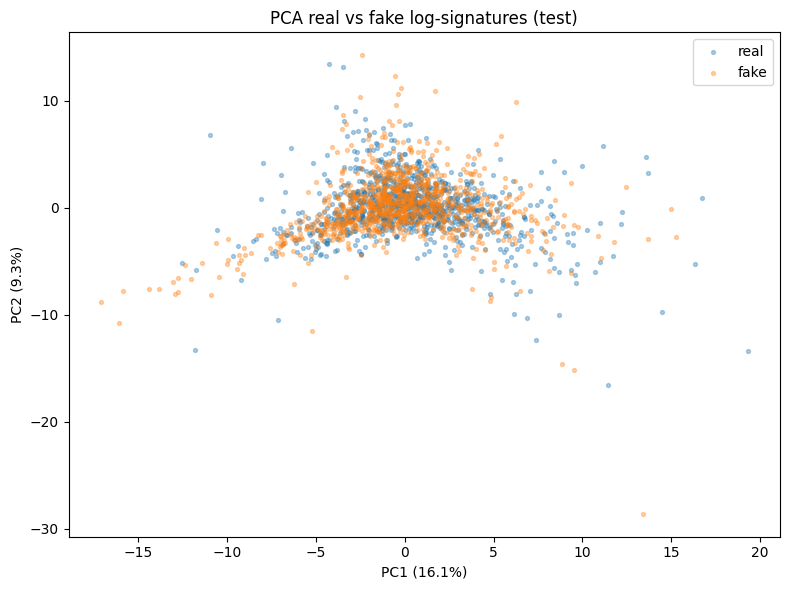

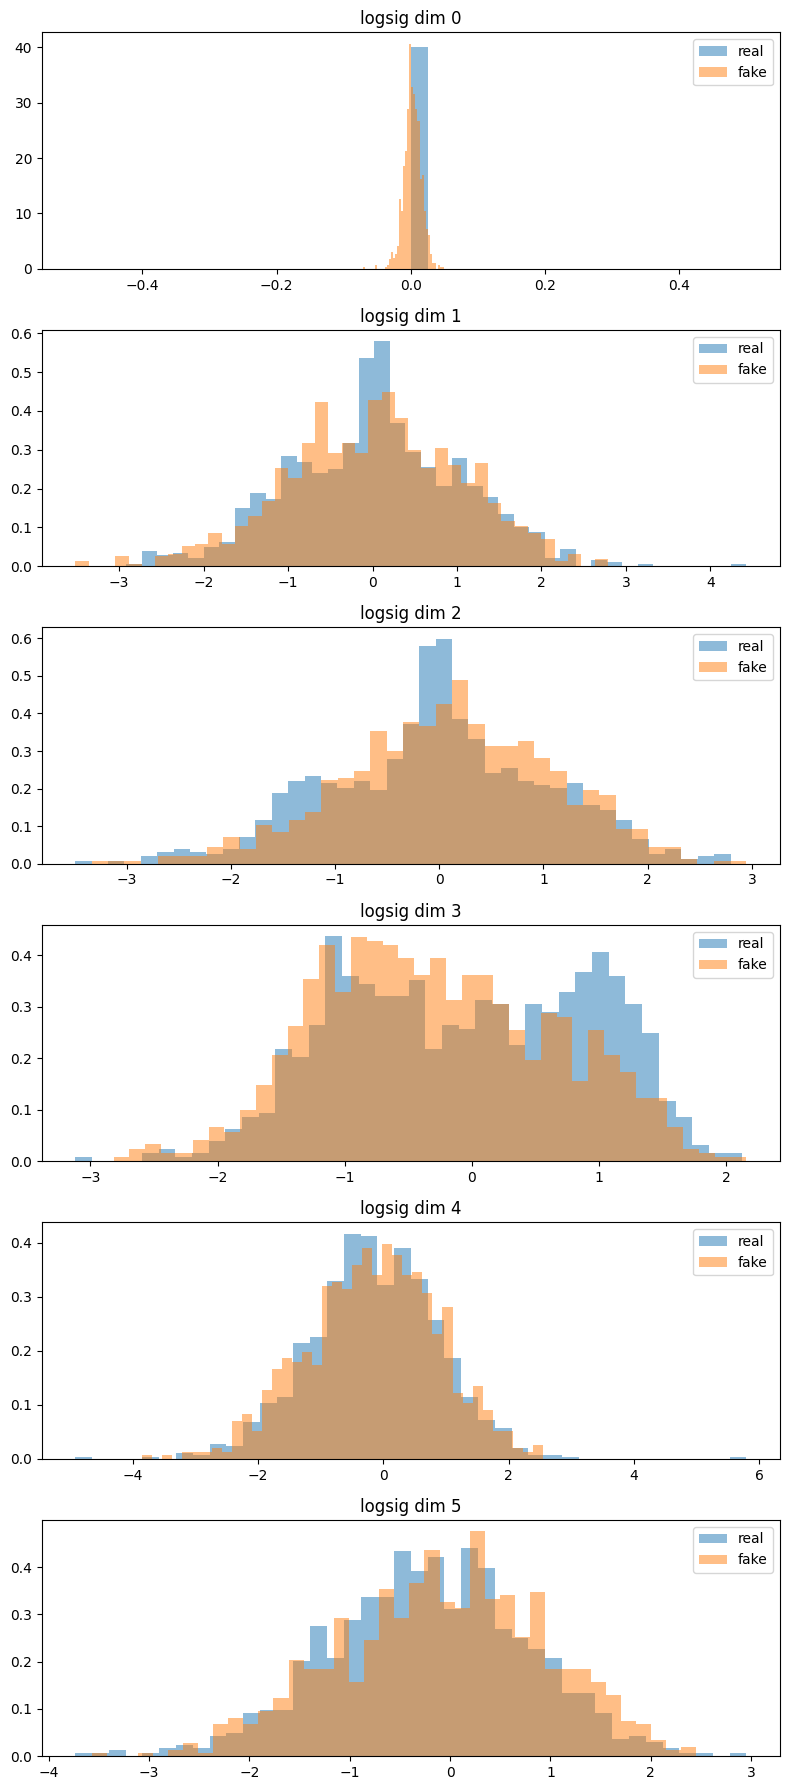

In [ ]:
if final_result is None:
    raise RuntimeError("No final_result available. Run training first.")

test_fake_std = generate_from_conditions(
    final_result["generator"],
    C_test,
    noise_dim=FINAL_CONFIG["noise_dim"],
    seed=GEN_SAMPLING_SEED,
    device=device,
)

test_metrics = evaluate_generator(
    final_result["generator"],
    y_val=Y_test,
    c_val=C_test,
    noise_dim=FINAL_CONFIG["noise_dim"],
    seed=GEN_SAMPLING_SEED,
    device=device,
)
print("Held-out TEST metrics:")
print(pd.Series(test_metrics))

pca_real_vs_fake(Y_test, test_fake_std, split_name="test")

# first few logsig marginals
marginal_diagnostic(Y_test, test_fake_std, cols=list(range(min(6, Y_test.shape[1]))), max_plots=6)

In [ ]:
print("=== Final Run Metrics ===")
print(f"Validation proxy score: {final_result['best']['metrics']['score']:.4f}")
print(f"Validation mmd_rbf:     {final_result['best']['metrics']['mmd_rbf']:.4f}")
print(f"Validation mean_gap:    {final_result['best']['metrics']['mean_gap']:.4f}")
print(f"Validation std_gap:     {final_result['best']['metrics']['std_gap']:.4f}")
print(f"Validation tail_gap:    {final_result['best']['metrics']['tail_gap']:.4f}")
print(f"Validation cov_gap:     {final_result['best']['metrics']['cov_gap']:.4f}")

print("\nHeld-out TEST proxy metrics:")
print(f"Test score:             {test_metrics['score']:.4f}")
print(f"Test mmd_rbf:           {test_metrics['mmd_rbf']:.4f}")
print(f"Test mean_gap:          {test_metrics['mean_gap']:.4f}")
print(f"Test std_gap:           {test_metrics['std_gap']:.4f}")
print(f"Test tail_gap:          {test_metrics['tail_gap']:.4f}")
print(f"Test cov_gap:           {test_metrics['cov_gap']:.4f}")

print("\nArtifacts:")
print(" ", CHECKPOINT_OUT.name)
print(" ", HISTORY_OUT.name)
print(" ", CONFIG_OUT.name)
print(" ", GENERATED_OUT.name)


=== Final Run Metrics ===
Validation proxy score: 142.2075
Validation mmd_rbf:     0.0046
Validation mean_gap:    0.6982
Validation std_gap:     1.1272
Validation tail_gap:    281.5804
Validation cov_gap:     0.4442

Held-out TEST proxy metrics:
Test score:             140.4841
Test mmd_rbf:           0.0078
Test mean_gap:          0.7124
Test std_gap:           0.8820
Test tail_gap:          278.6504
Test cov_gap:           0.3639

Artifacts:
  sigcwgan_best_optuna_rawproxy_v1.pt
  sigcwgan_history_optuna_rawproxy_v1.json
  sigcwgan_config_optuna_rawproxy_v1.json
  sigcwgan_generated_logsigs_optuna_rawproxy_v1.parquet


### CELL 15 — Targeted reruns

- Changed training hyperparameters only: rerun **CELL 6 onward**
- Changed Optuna settings only: rerun **CELL 9 onward**
- Want a fresh generated parquet from the saved best model after changing only sampling seed: rerun **CELL 13 onward**
- Changed file paths / moved project folder: rerun **CELL 2 onward**